# Analiza ogłoszeń mieszkań w Krakowie - Kacper Osmola 2026

In [5]:
!pip install geopandas


In [6]:
!pip install beautifulsoup4

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn3

import geopandas
import zipfile, re, os
import requests
from bs4 import BeautifulSoup
import threading
from time import sleep

# Data ingestion

In [ ]:
url = 'https://www.otodom.pl/pl/wyniki/sprzedaz/mieszkanie/malopolskie/krakow/krakow/krakow?limit=72&page='
headers = {'User-Agent' : 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safari/537.36'}
pages = []
for i in range(1, 180):
  page = requests.get(url + str(i), headers=headers)
  pages.append(page)
  if i % 20 == 0:
    print(i)
  sleep(0.5)

20
40
60
80
100
120
140
160


In [ ]:
offerts_links = []
for i, page in enumerate(pages):
  if i % 20 == 0:
    print(i)
  soup = BeautifulSoup(page.content, 'html.parser')
  main_block = soup.select_one('div', _class = 'search.listing.organic')
  offerts = main_block.find_all('li')
  for li in offerts:
    try:
      link = li.find('a')['href']
      if '/pl/oferta' in link:
        offerts_links.append(link)
    except:
      pass

0
20
40
60
80
100
120
140
160


In [ ]:
offerts_pages = []
chosen = np.random.choice(offerts_links, 2000)
for i, link in enumerate(chosen): # this would run for 5 hours if I wanted to request every site...
  if i % 100 == 0:
    print(i)
  new_page = requests.get(f'https://www.otodom.pl/{link}', headers=headers)
  offerts_pages.append(new_page.content)
  sleep(0.5)
  if new_page.status_code != 200:
    print(i, new_page.status_code)

0
45 410
100
200
294 410
300
368 410
400
421 410
488 410
500
568 410
600
639 410
700
703 410
800
810 410
900
952 410
1000
1100
1128 410
1178 410
1200
1227 410
1300
1378 410
1400
1412 410
1487 410
1499 410
1500
1536 410
1600
1700
1715 410
1720 410
1753 410
1794 410
1800
1801 410
1889 410
1894 410
1896 410
1900


In [ ]:
pre_df = {'Link': [], 'Title': [], 'Price': [], 'Powierzchnia':[], 'Liczba pokoi':[], 'Ogrzewanie':[], 'Piętro':[], 'Czynsz': []
          , 'Stan wykończenia': [], 'Rynek' : [], 'Forma własności': [], 'Dostępne od' : [], 'Informacje dodatkowe':[], 'Rok budowy':[],
          'Winda':[],'Rodzaj zabudowy':[], 'Bezpieczeństwo':[],'Lokalizacja': []}
for i, page in enumerate(offerts_pages):
  if i % 500 == 0:
    print(i)
  soup = BeautifulSoup(page, 'html.parser')
  title = soup.select_one('h1', {'data-cy':'adPageAdTitle'})
  title = title.text.strip() if title != None else np.nan
  price = soup.select_one('strong', {'data-sentry-element':'Price'})
  price = price.text.replace('zł', '').replace(' ', '').strip() if price != None else np.nan
  location = soup.select_one('a.css-1eowip8.e1aypsbg1')
  location = location.text.strip() if location != None else np.nan
  pre_df['Price'].append(price)
  pre_df['Link'].append(offerts_links[i])
  pre_df['Title'].append(title)
  pre_df['Lokalizacja'].append(location)
  rows = soup.find_all('div', class_ = 'css-1xw0jqp efdvw050')
  for row in rows:
    double = row.find_all('div')
    attr = double[0].text.replace(':','').strip()
    value = double[1].text
    if attr in pre_df:
      pre_df[attr].append(value)
  for col in pre_df:
    if len(pre_df[col]) < i + 1:
      pre_df[col].append(np.nan)


0
500
1000
1500


Jako że sam web scraping zajmuje dużo czasu, a progres resetuje się na google collabie, zapisuję w formie jsona słownik aby kontynuować czyszczenie danych później

In [ ]:
import json
with open('offerts.json', 'w') as f:
  json.dump(pre_df, f)

## Importing json

In [8]:
import json
with open('offerts.json','r') as f:
  json_str = f.read()
  pre_df = json.loads(json_str)

In [9]:
pre_df['Powierzchnia'] = [str(i).split()[0] for i in pre_df['Powierzchnia']]
pre_df['Piętro'] = [np.nan if i == 'brak informacji' else i for i in pre_df['Piętro']]
pre_df['Czynsz'] = [str(i).split()[0] for i in pre_df['Czynsz']]
pre_df['Pięter'] = [str(i).split('/')[1] if len(str(i).split('/')) > 1 else np.nan for i in pre_df['Piętro']]
pre_df['Piętro'] = [str(i).split('/')[0] for i in pre_df['Piętro']]
pre_df['District'] = [str(i).split(',')[-3].strip() if len(str(i).split(',')) > 3 else np.nan for i in pre_df['Lokalizacja']]
pre_df['Price'] = [float(i) if str(i).isnumeric() else np.nan for i  in pre_df['Price']]
pre_df['Powierzchnia'] = [float(i) for i in pre_df['Powierzchnia']]

In [10]:
df = pd.DataFrame(pre_df)
df.head()

,Link,Title,Price,Powierzchnia,Liczba pokoi,Ogrzewanie,Piętro,Czynsz,Stan wykończenia,Rynek,Forma własności,Dostępne od,Informacje dodatkowe,Rok budowy,Winda,Rodzaj zabudowy,Bezpieczeństwo,Lokalizacja,Pięter,District
0,/pl/oferta/1-pokojowe-z-balkonem-do-wlasnej-ar...,NaN,NaN,33.00,NaN,NaN,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,brak informacji,NaN,NaN,NaN
1,/pl/oferta/przestronne-3-pokojowe-mieszkanie-z...,Aktualny Apartament Centrum Bez PCC Gotowy,1219000.0,50.50,3,miejskie,3,brak,do wykończenia,pierwotny,pełna własność,brak informacji,balkon garaż/miejsce parkingowe,2025,tak,apartamentowiec,monitoring / ochrona,"ul. Masarska, Grzegórzki, Grzegórzki, Kraków, ...",4,Grzegórzki
2,/pl/oferta/2-pokojowe-mieszkanie-41m2-balkon-I...,2-pokojowe mieszkanie 39m2 Bezpośrednio,633333.0,39.46,2,brak informacji,1,brak,do wykończenia,pierwotny,pełna własność,2027-06-15,garaż/miejsce parkingowe,2027,tak,NaN,NaN,"ul. Agatowa, Złocień, Bieżanów-Prokocim, Krakó...",4,Bieżanów-Prokocim
3,/pl/oferta/2-pokojowe-mieszkanie-42m2-balkon-I...,Bezpośrednio | Gotowe do zamieszkania | Wykońc...,883000.0,50.23,3,brak informacji,7,800,brak informacji,wtórny,pełna własność,2026-01-01,balkon garaż/miejsce parkingowe oddzielna kuchnia,2023,tak,NaN,monitoring / ochrona,"ul. Bolesława Orlińskiego, Czyżyny Lotnisko, C...",7,Czyżyny
4,/pl/oferta/2-pokojowe-mieszkanie-36m2-balkon-b...,Antresola | Park 2000m2 | Klima | Ogrzewanie p...,1259000.0,101.90,4,gazowe,1,brak,do wykończenia,pierwotny,brak informacji,2027-03-31,balkon dwupoziomowe,2027,nie,szeregowiec,monitoring / ochrona teren zamknięty,"ul. Sołtysowska, Łęg, Czyżyny, Kraków, małopol...",1,Czyżyny


In [11]:
df['District'].unique()

array([nan, 'Grzegórzki', 'Bieżanów-Prokocim', 'Czyżyny',
       'Podgórze Duchackie', 'Prądnik Czerwony', 'Dębniki',
       'Prądnik Biały', 'Zielonki', 'Podgórze', 'Krowodrza', 'Bronowice',
       'Stare Miasto', 'Nowa Huta', 'Zwierzyniec', 'Swoszowice',
       'Mistrzejowice', 'Mogilany', 'Bieńczyce', 'Wzgórza Krzesławickie',
       'Łagiewniki-Borek Fałęcki', 'Skawina', 'Wieliczka', 'Wielka Wieś'],
      dtype=object)

In [12]:
df = df[df['District'] != 'Wieliczka']
df = df[df['District'] != 'Mogilany']
df = df[df['District'] != 'Zielonki']
df

,Link,Title,Price,Powierzchnia,Liczba pokoi,Ogrzewanie,Piętro,Czynsz,Stan wykończenia,Rynek,Forma własności,Dostępne od,Informacje dodatkowe,Rok budowy,Winda,Rodzaj zabudowy,Bezpieczeństwo,Lokalizacja,Pięter,District
0,/pl/oferta/1-pokojowe-z-balkonem-do-wlasnej-ar...,NaN,NaN,33.00,NaN,NaN,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,brak informacji,NaN,NaN,NaN
1,/pl/oferta/przestronne-3-pokojowe-mieszkanie-z...,Aktualny Apartament Centrum Bez PCC Gotowy,1219000.0,50.50,3,miejskie,3,brak,do wykończenia,pierwotny,pełna własność,brak informacji,balkon garaż/miejsce parkingowe,2025,tak,apartamentowiec,monitoring / ochrona,"ul. Masarska, Grzegórzki, Grzegórzki, Kraków, ...",4,Grzegórzki
2,/pl/oferta/2-pokojowe-mieszkanie-41m2-balkon-I...,2-pokojowe mieszkanie 39m2 Bezpośrednio,633333.0,39.46,2,brak informacji,1,brak,do wykończenia,pierwotny,pełna własność,2027-06-15,garaż/miejsce parkingowe,2027,tak,NaN,NaN,"ul. Agatowa, Złocień, Bieżanów-Prokocim, Krakó...",4,Bieżanów-Prokocim
3,/pl/oferta/2-pokojowe-mieszkanie-42m2-balkon-I...,Bezpośrednio | Gotowe do zamieszkania | Wykońc...,883000.0,50.23,3,brak informacji,7,800,brak informacji,wtórny,pełna własność,2026-01-01,balkon garaż/miejsce parkingowe oddzielna kuchnia,2023,tak,NaN,monitoring / ochrona,"ul. Bolesława Orlińskiego, Czyżyny Lotnisko, C...",7,Czyżyny
4,/pl/oferta/2-pokojowe-mieszkanie-36m2-balkon-b...,Antresola | Park 2000m2 | Klima | Ogrzewanie p...,1259000.0,101.90,4,gazowe,1,brak,do wykończenia,pierwotny,brak informacji,2027-03-31,balkon dwupoziomowe,2027,nie,szeregowiec,monitoring / ochrona teren zamknięty,"ul. Sołtysowska, Łęg, Czyżyny, Kraków, małopol...",1,Czyżyny
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,/pl/oferta/promocja-3-pokoje-gotowe-do-odbioru...,Gotowy Apartament Pod Krótki Najem od Właściciela,799000.0,56.25,3,miejskie,parter,350,do zamieszkania,wtórny,pełna własność,brak informacji,brak informacji,2020,tak,blok,monitoring / ochrona,"gen. Antoniego Józefa Madalińskiego, Dębniki, ...",3,Dębniki
1996,/pl/oferta/promocja-2-pokoje-gotowe-do-odbioru...,2 pok./ oddana inwestycja - bez Pcc/ Ruczaj,539000.0,33.37,2,miejskie,1,0/miesiąc,do wykończenia,pierwotny,pełna własność,2026-01-29,balkon garaż/miejsce parkingowe,2025,nie,blok,monitoring / ochrona,"Jana Kantego Federowicza, Skotniki, Dębniki, K...",3,Dębniki
1997,/pl/oferta/promocja-2-pokoje-gotowe-do-odbioru...,wysoki standard | dwustronne | widok na Kopiec,638000.0,37.00,2,miejskie,4,600,do wykończenia,pierwotny,pełna własność,2025-11-03,balkon garaż/miejsce parkingowe,2025,tak,blok,monitoring / ochrona,"Samuela Bogumiła Lindego, Bronowice, Bronowice...",7,Bronowice
1998,/pl/oferta/2-pokoje-krowodrza-klimatyzacja-w-c...,"mIeszkanie na sprzedaż 38,75m2|Bieżanowska",600000.0,38.75,2,gazowe,parter,420,do zamieszkania,wtórny,pełna własność,brak informacji,ogródek garaż/miejsce parkingowe piwnica,2013,nie,blok,teren zamknięty,"ul. Wojciecha Darasza, Stary Prokocim, Bieżanó...",3,Bieżanów-Prokocim


In [13]:
pre_df = {'Powierzchnia':'Surface', 'Liczba pokoi':'Rooms', 'Ogrzewanie':'Heating', 'Piętro':'Floor', 'Czynsz': 'Rent'
          , 'Stan wykończenia': 'Finishing state', 'Rynek' : 'Market', 'Forma własności': 'Ownership', 'Dostępne od' : 'Available since'
          , 'Informacje dodatkowe':'Info', 'Rok budowy': 'Built in',
          'Winda':'Lift','Rodzaj zabudowy':'Building type', 'Bezpieczeństwo':'Safety','Lokalizacja': 'Location'}
for col in pre_df:
  df = df.rename(columns={col: pre_df[col]})

In [14]:
df.head()

,Link,Title,Price,Surface,Rooms,Heating,Floor,Rent,Finishing state,Market,Ownership,Available since,Info,Built in,Lift,Building type,Safety,Location,Pięter,District
0,/pl/oferta/1-pokojowe-z-balkonem-do-wlasnej-ar...,NaN,NaN,33.00,NaN,NaN,nan,nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,brak informacji,NaN,NaN,NaN
1,/pl/oferta/przestronne-3-pokojowe-mieszkanie-z...,Aktualny Apartament Centrum Bez PCC Gotowy,1219000.0,50.50,3,miejskie,3,brak,do wykończenia,pierwotny,pełna własność,brak informacji,balkon garaż/miejsce parkingowe,2025,tak,apartamentowiec,monitoring / ochrona,"ul. Masarska, Grzegórzki, Grzegórzki, Kraków, ...",4,Grzegórzki
2,/pl/oferta/2-pokojowe-mieszkanie-41m2-balkon-I...,2-pokojowe mieszkanie 39m2 Bezpośrednio,633333.0,39.46,2,brak informacji,1,brak,do wykończenia,pierwotny,pełna własność,2027-06-15,garaż/miejsce parkingowe,2027,tak,NaN,NaN,"ul. Agatowa, Złocień, Bieżanów-Prokocim, Krakó...",4,Bieżanów-Prokocim
3,/pl/oferta/2-pokojowe-mieszkanie-42m2-balkon-I...,Bezpośrednio | Gotowe do zamieszkania | Wykońc...,883000.0,50.23,3,brak informacji,7,800,brak informacji,wtórny,pełna własność,2026-01-01,balkon garaż/miejsce parkingowe oddzielna kuchnia,2023,tak,NaN,monitoring / ochrona,"ul. Bolesława Orlińskiego, Czyżyny Lotnisko, C...",7,Czyżyny
4,/pl/oferta/2-pokojowe-mieszkanie-36m2-balkon-b...,Antresola | Park 2000m2 | Klima | Ogrzewanie p...,1259000.0,101.90,4,gazowe,1,brak,do wykończenia,pierwotny,brak informacji,2027-03-31,balkon dwupoziomowe,2027,nie,szeregowiec,monitoring / ochrona teren zamknięty,"ul. Sołtysowska, Łęg, Czyżyny, Kraków, małopol...",1,Czyżyny


In [15]:
df = df.dropna(subset=['Rooms', 'Price'])
df.isna().sum()

,0
Link,0
Title,0
Price,0
Surface,0
Rooms,0
Heating,0
Floor,0
Rent,0
Finishing state,0
Market,0


STOP

- rozkład cen według dzielnicy
- średnia cena na metr na dzielnice
- ogrzewanie a cena
- wysokość budynku według dzielnicy

# Analysis

## Price and surface distribution

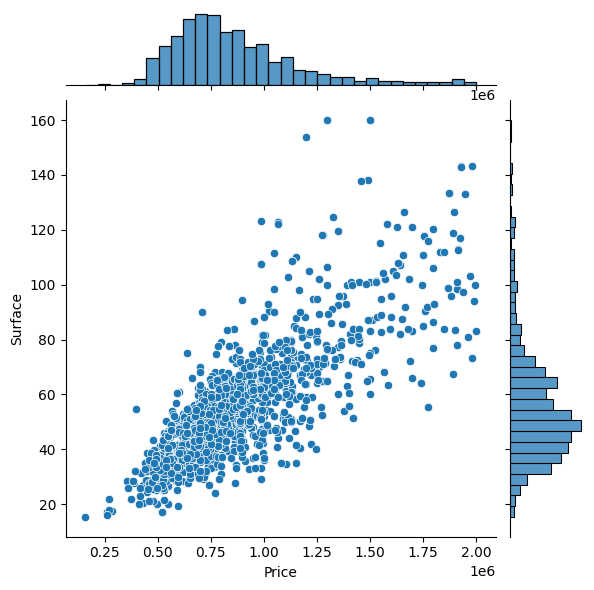

In [16]:
sns.jointplot(data= df[(df.Price <= 2000000) & (df.Surface <= 200)], x='Price', y='Surface')

## Districts

<Axes: >

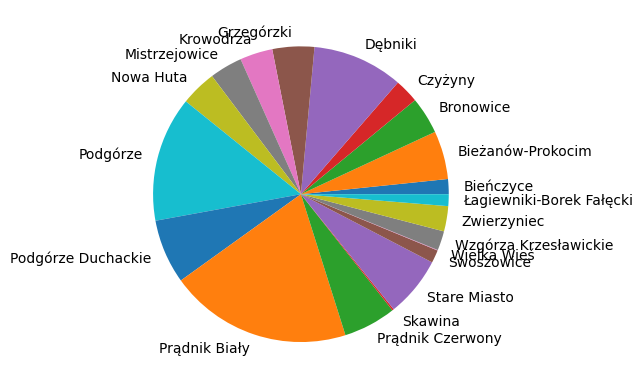

In [17]:
df.groupby('District')['Title'].count().plot(kind='pie', ylabel='')

## Price per square meter distribution

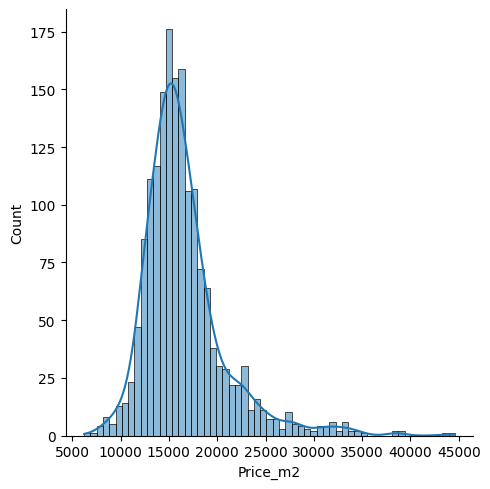

In [18]:
df['Price_m2'] = df['Price'] / df['Surface']
normal_price = df[df.Price_m2 <= 50000]
sns.displot(data = normal_price['Price_m2'], kde=True)

## Avarage price per square meter by floor

In [19]:
df['Floor'].unique()

array(['3', '1', '7', 'parter', '2', '8', '5', '4', '9', '> 10', '10',
       '6', 'nan', 'suterena'], dtype=object)

In [20]:
df['Floor'] = df['Floor'].replace('', np.nan)
df['Floor'] = df['Floor'].replace('nan', np.nan)
df = df.dropna(subset= ['Floor'])

In [21]:
sorter = {'suterena': 0, 'parter': 1, '1': 2, '2': 3, '3': 4, '4' : 5, '5':6, '6':7, '7': 8, '8': 9, '9': 10, '10': 11, '> 10': 12}

<Axes: title={'center': 'Avg price per m2 for each floor'}, xlabel='Floor_abs', ylabel='price per m2'>

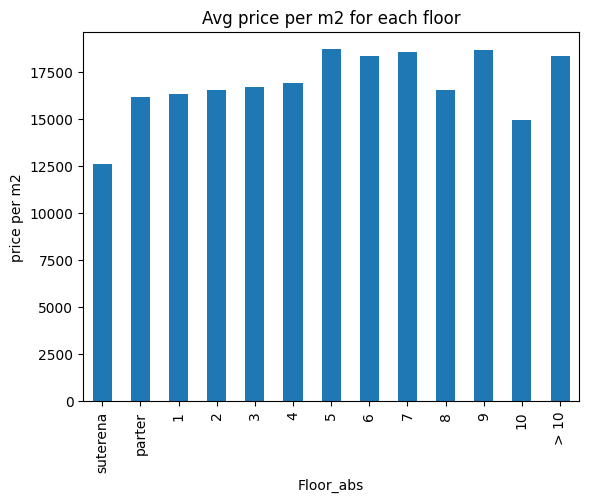

In [22]:
df['Floor_abs'] = df['Floor'].apply(lambda x : str(x).split('/')[0].strip())
to_plot = df[df.Floor_abs != 'nan']
to_plot = to_plot.groupby('Floor_abs')['Price_m2'].mean()
to_plot = to_plot[to_plot != 'nan']

to_plot.sort_index(key=lambda x: [sorter[i] for i in x]).plot(kind='bar', title='Avg price per m2 for each floor', ylabel='price per m2')

## Price per square meter by finishing condition

<Axes: xlabel='Finishing state', ylabel='Price_m2'>

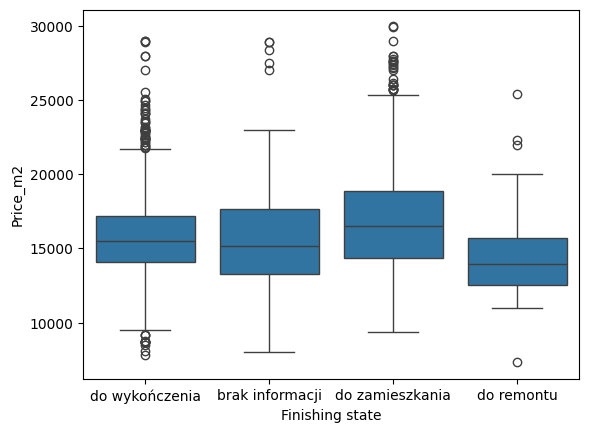

In [23]:
to_plot = df[df.Price_m2 < 30000]
sns.boxplot(x = to_plot['Finishing state'], y=to_plot.Price_m2)

In [24]:
url = 'https://gis-support.pl/wp-content/uploads/dzielnice_Krakowa.zip'
r = requests.get(url, allow_redirects=True)
f = open('dzielnice_Krakowa.zip', 'wb')
f.write(r.content)
f.close()

In [25]:
districts = geopandas.read_file('zip://dzielnice_Krakowa.zip/dzielnice_Krakowa.dbf', encoding='utf-8')
districts['nazwa'] = districts['nazwa'].str.upper()
districts.head(3)

,objectid,mslink,mapid,id_dzielni,nr_dzielni,powierzchn,nazwa,nazwa_peln,opis,data_aktua,st_area(sh,st_length(,geometry
0,1.0,1.0,3013.0,1.0,I,5567646.0,STARE MIASTO,Dzielnica I Stare Miasto,UCHWALA NR XCIX/1495/14 RADY MIASTA KRAKOWA,2014-04-01,5.567646e+06,11730.268840,"POLYGON ((566097.26 244329.716, 566097.477 244..."
1,2.0,2.0,3013.0,2.0,II,5845232.0,GRZEGÓRZKI,Dzielnica II Grzegórzki,UCHWAŁA NR XCIX/1496/14 RADY MIASTA KRAKOWA,2014-04-01,5.845232e+06,11863.161038,"POLYGON ((567784.5 244043.139, 567786.287 2440..."
2,3.0,3.0,3013.0,3.0,III,6437857.0,PRĄDNIK CZERWONY,Dzielnica III Prądnik Czerwony,UCHWAŁA NR XCIX/1497/14 RADY MIASTA KRAKOWA,2014-04-01,6.437857e+06,13926.658887,"POLYGON ((567758.514 246401.517, 567774.358 24..."


## Avarage price per square meter by district

In [26]:
to_merge = df[df['Price_m2'] <= 100000]
to_merge['District'] = to_merge['District'].apply(lambda x: x.upper())
to_merge = to_merge.groupby('District')['Price_m2'].mean()
to_merge = pd.merge(districts, to_merge, left_on='nazwa', right_on='District')

In [27]:
def graph_map(df, variable):
  fig, ax = plt.subplots(figsize=(10, 10))
  df.plot(column=variable, cmap='summer_r', linewidth=1.5, ax=ax)
  vmin, vmax = df[variable].min(), df[variable].max()
  sm = plt.cm.ScalarMappable(cmap='summer_r', norm=plt.Normalize(vmin=vmin, vmax=vmax))
  sm._A = []
  fig.colorbar(sm, shrink=0.5, ax=ax)
  plt.title('Average price per m2 in districts')
  ax.axis('off')

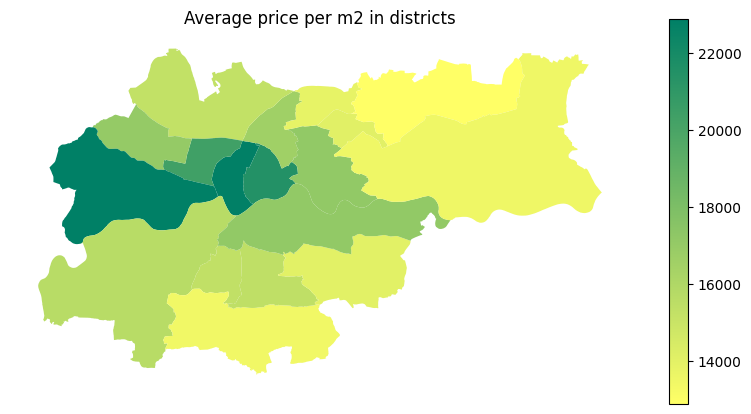

In [28]:
graph_map(to_merge, 'Price_m2')

## Avarage building age by district

/tmp/ipykernel_1753/2292530482.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_merge['Built in'] = to_merge['Built in'].apply(lambda x: int(x))


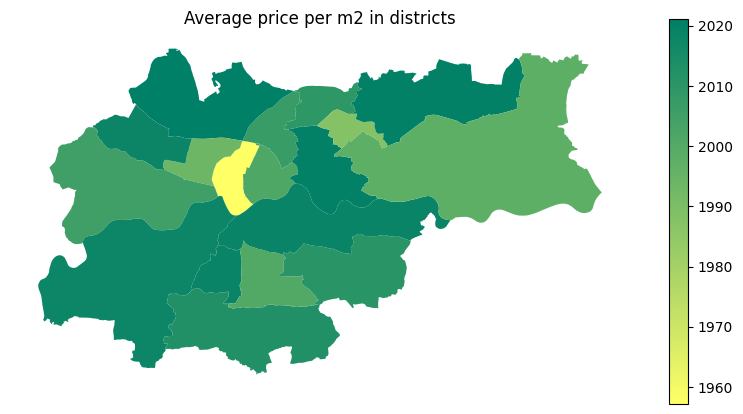

In [29]:
to_merge = df
to_merge['District'] = to_merge['District'].apply(lambda x: x.upper())
to_merge = to_merge.dropna(subset=['Built in'])
to_merge['Built in'] = to_merge['Built in'].apply(lambda x: int(x))
to_merge = to_merge.groupby('District')['Built in'].mean()
to_merge = pd.merge(districts, to_merge, left_on='nazwa', right_on='District')
graph_map(to_merge, 'Built in')

## Price per square meter distribution by building type

In [46]:
to_plot = df
to_plot['Building type'] = to_plot['Building type'].replace('nan', np.nan)
to_plot = to_plot.dropna(subset=['Building type'])
to_plot = to_plot[to_plot['Price_m2'] < 40000]
words = to_plot['Building type'].unique()

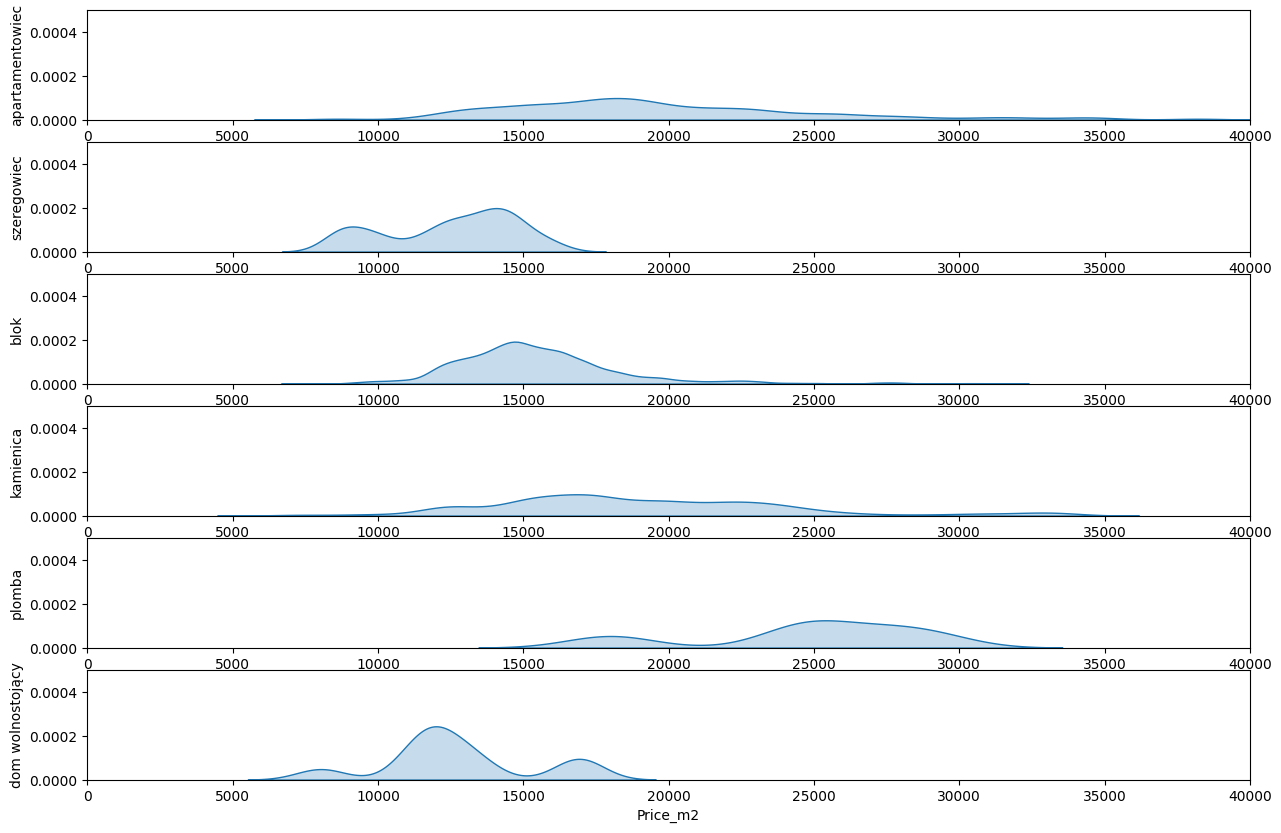

In [53]:
fig, axs = plt.subplots(len(words),1, figsize=(15, 10))
for i, word in enumerate(words):
  subset = to_plot[to_plot['Building type'] == word]
  sns.kdeplot(subset['Price_m2'], fill=True, bw_adjust = 0.5, ax = axs[i])
  axs[i].set_xlim(0, 40000)
  axs[i].set_ylim(0, 0.0005)
  axs[i].set_ylabel(word)